In [1]:
import os
import cv2
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import kagglehub

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Subset, DataLoader
from torchvision import transforms, datasets
import torchvision.models as models


/opt/anaconda3/lib/python3.12/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


In [2]:
torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using Device:", device)

Using Device: cpu


downloading dataset and file path

In [3]:
downloaded_path = kagglehub.dataset_download("orvile/brain-cancer-mri-dataset")
resolved_paths = glob.glob(os.path.join(downloaded_path, '**/Brain_Cancer'), recursive=True)
base_path = resolved_paths[0] if resolved_paths else downloaded_path


In [4]:
categories = ['brain_glioma', 'brain_menin', 'brain_tumor']
num_classes = len(categories)

In [16]:
full_image_path_list = []
labels = []

for cls in categories:
    cls_path = os.path.join(base_path, cls)
    for img_name in os.listdir(cls_path):
        full_image_path_list.append(os.path.join(cls_path, img_name))
        labels.append(cls)

df = pd.DataFrame({
    'image': full_image_path_list,
    'label': labels
})

print(df)

                                                  image         label
0     /Users/macbookpro/.cache/kagglehub/datasets/or...  brain_glioma
1     /Users/macbookpro/.cache/kagglehub/datasets/or...  brain_glioma
2     /Users/macbookpro/.cache/kagglehub/datasets/or...  brain_glioma
3     /Users/macbookpro/.cache/kagglehub/datasets/or...  brain_glioma
4     /Users/macbookpro/.cache/kagglehub/datasets/or...  brain_glioma
...                                                 ...           ...
6051  /Users/macbookpro/.cache/kagglehub/datasets/or...   brain_tumor
6052  /Users/macbookpro/.cache/kagglehub/datasets/or...   brain_tumor
6053  /Users/macbookpro/.cache/kagglehub/datasets/or...   brain_tumor
6054  /Users/macbookpro/.cache/kagglehub/datasets/or...   brain_tumor
6055  /Users/macbookpro/.cache/kagglehub/datasets/or...   brain_tumor

[6056 rows x 2 columns]


In [17]:

df['label_id'], uniques = pd.factorize(df['label'])
num_classes = len(uniques)
print("Class Names:", uniques.tolist())

Class Names: ['brain_glioma', 'brain_menin', 'brain_tumor']


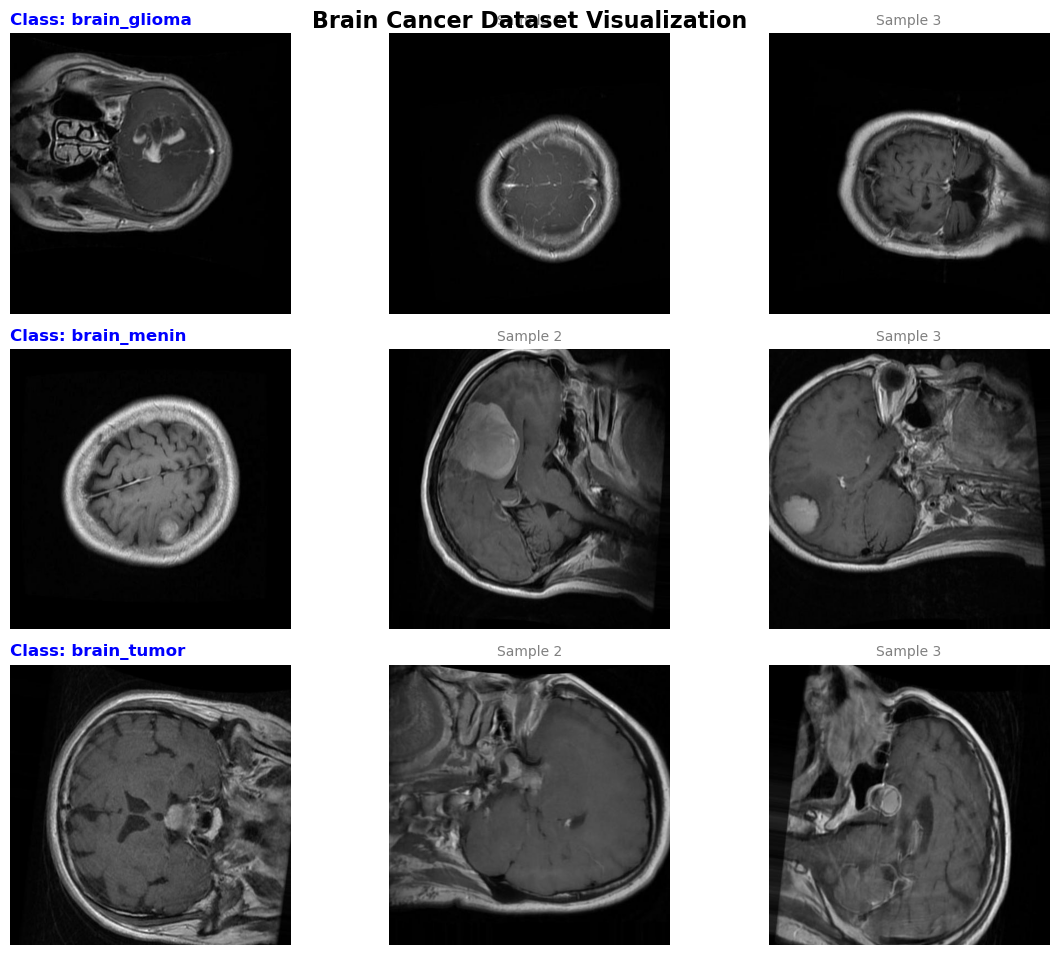

In [19]:
import random
import matplotlib.pyplot as plt

images_per_class = 3
classes = ['brain_glioma', 'brain_menin', 'brain_tumor']

fig, axes = plt.subplots(len(classes), images_per_class, figsize=(12, 10))
fig.suptitle('Brain Cancer Dataset Visualization', fontsize=16, fontweight='bold', y=0.95)

samples = full_dataset.samples
class_to_idx = full_dataset.class_to_idx

for class_idx, class_name in enumerate(classes):
    target_idx = class_to_idx[class_name]
    class_samples = [path for path, idx in samples if idx == target_idx]
    selected_images = random.sample(class_samples, images_per_class)
    
    for img_idx, img_path in enumerate(selected_images):
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        ax = axes[class_idx, img_idx]
        ax.imshow(img)
        ax.axis('off')
        
        if img_idx == 0:
            ax.set_title(f"Class: {class_name}", fontsize=12, loc='left', color='blue', fontweight='bold')
        else:
            ax.set_title(f"Sample {img_idx+1}", fontsize=10, color='gray')

plt.tight_layout()
plt.show()

In [5]:
#data transfroms and loaders
train_transforms = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transforms = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [6]:
full_dataset = datasets.ImageFolder(root=base_path)
train_size = int(0.8 * len(full_dataset))
test_size = len(full_dataset) - train_size
train_dataset_full, test_dataset_full = torch.utils.data.random_split(full_dataset, [train_size, test_size])



In [7]:
class TransformedSubset(torch.utils.data.Dataset):
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform
        
    def __getitem__(self, index):
        x, y = self.subset[index]
        if self.transform:
            x = self.transform(x)
        return x, y
        
    def __len__(self):
        return len(self.subset)

In [8]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


In [9]:
train_dataset = TransformedSubset(train_dataset_full, transform=train_transforms)
test_dataset = TransformedSubset(test_dataset_full, transform=test_transforms)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0)

print("Train size:", len(train_dataset))
print("Test size:", len(test_dataset))

Train size: 4844
Test size: 1212


In [10]:
class EnhancedCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            # layer1
            nn.Conv2d(3, 64, kernel_size=3, padding='same'),
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.MaxPool2d(2), 
            
            # layer2
            nn.Conv2d(64, 128, kernel_size=3, padding='same'),
            nn.ReLU(),
            nn.BatchNorm2d(128),
            nn.MaxPool2d(2), 
            
            # layer3
            nn.Conv2d(128, 256, kernel_size=3, padding='same'),
            nn.ReLU(),
            nn.BatchNorm2d(256),
            nn.MaxPool2d(2), 
            
            # layer4
            nn.Conv2d(256, 512, kernel_size=3, padding='same'),
            nn.ReLU(),
            nn.BatchNorm2d(512),
            nn.MaxPool2d(2)  
        )
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512 * 8 * 8, 512), 
            nn.ReLU(),
            nn.Dropout(0.4), 
            nn.Linear(512, 128),           
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [11]:
model = EnhancedCNN(num_classes=num_classes).to(device)


In [12]:
learning_rate = 0.0002 
epochs = 15            
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=1e-3)

In [13]:
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=1, factor=0.5)

best_val_loss = float('inf')
patience = 4 
counter = 0

train_losses = []
val_losses = []


# --- ৫. ট্রেইনিং এবং ভ্যালিডেশন লুপ ---
for epoch in range(epochs):
    model.train()
    total_loss = 0

    for batch_features, batch_labels in train_loader:
        batch_features = batch_features.to(device)
        batch_labels = batch_labels.to(device)

        outputs = model(batch_features)
        loss = criterion(outputs, batch_labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    train_loss = total_loss / len(train_loader)
    train_losses.append(train_loss)
    model.eval()
    val_loss = 0

    with torch.no_grad():
        for batch_features, batch_labels in test_loader:
            batch_features = batch_features.to(device)
            batch_labels = batch_labels.to(device)

            outputs = model(batch_features)
            loss = criterion(outputs, batch_labels)

            val_loss += loss.item()

    val_loss = val_loss / len(test_loader)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

    scheduler.step(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0
        torch.save(model.state_dict(), "best_enhanced_cnn_model.pth")
    else:
        counter += 1

    if counter >= patience:
        print("Early stopping triggered! ")
        break


Epoch 1, Train Loss: 0.8502, Val Loss: 0.6234
Epoch 2, Train Loss: 0.6316, Val Loss: 0.5967
Epoch 3, Train Loss: 0.5574, Val Loss: 0.5203
Epoch 4, Train Loss: 0.5140, Val Loss: 0.4474
Epoch 5, Train Loss: 0.4878, Val Loss: 0.4150
Epoch 6, Train Loss: 0.4601, Val Loss: 0.4008
Epoch 7, Train Loss: 0.4395, Val Loss: 0.4085
Epoch 8, Train Loss: 0.4259, Val Loss: 0.4039
Epoch 9, Train Loss: 0.3937, Val Loss: 0.3576
Epoch 10, Train Loss: 0.3815, Val Loss: 0.3546
Epoch 11, Train Loss: 0.3709, Val Loss: 0.3642
Epoch 12, Train Loss: 0.3631, Val Loss: 0.3474
Epoch 13, Train Loss: 0.3623, Val Loss: 0.3782
Epoch 14, Train Loss: 0.3543, Val Loss: 0.3427
Epoch 15, Train Loss: 0.3543, Val Loss: 0.3496


In [14]:
def evaluate(loader):
    model.eval()
    total, correct = 0, 0
    with torch.no_grad():
        for batch_features, batch_labels in loader:
            batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
            outputs = model(batch_features)
            _, predicted = torch.max(outputs, 1)
            total += batch_labels.size(0)
            correct += (predicted == batch_labels).sum().item()
    return correct / total

test_acc = evaluate(test_loader)
print(f"Final Test Accuracy: {test_acc * 100:.2f}%")
train_acc = evaluate(train_loader)
print(f"Final Train Accuracy: {train_acc * 100:.2f}%")

Final Test Accuracy: 97.69%
Final Train Accuracy: 99.07%


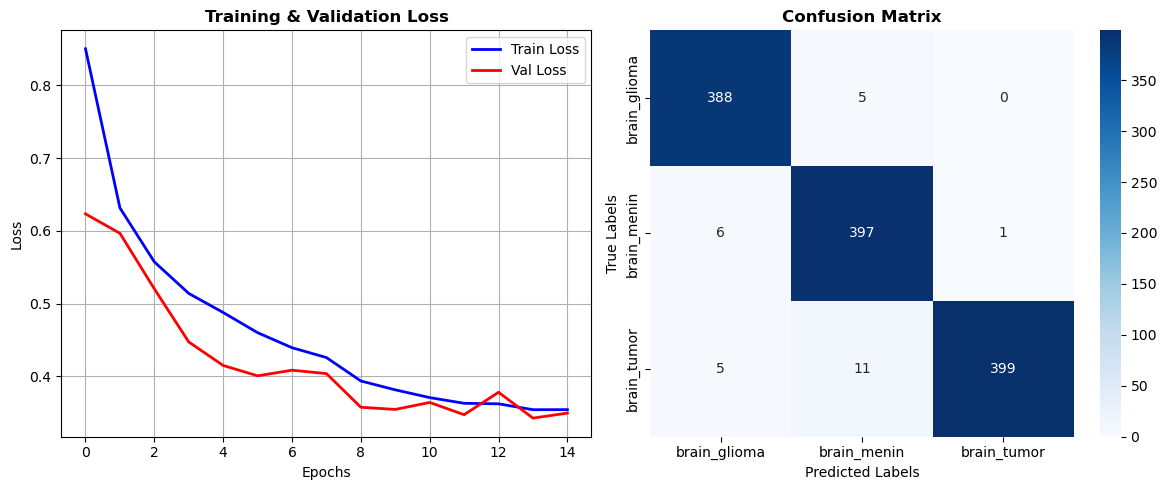

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

plt.figure(figsize=(12, 5))


plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss', color='blue', linewidth=2)
plt.plot(val_losses, label='Val Loss', color='red', linewidth=2)
plt.title('Training & Validation Loss', fontsize=12, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)


all_preds = []
all_labels = []
model.eval()

with torch.no_grad():
    for batch_features, batch_labels in test_loader:
        batch_features = batch_features.to(device)
        outputs = model(batch_features)
        _, predicted = torch.max(outputs, 1)
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(batch_labels.numpy())


cm = confusion_matrix(all_labels, all_preds)


plt.subplot(1, 2, 2)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=categories, yticklabels=categories)
plt.title('Confusion Matrix', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')

plt.tight_layout()
plt.show()

In [21]:
from sklearn.metrics import classification_report
print(classification_report(all_labels, all_preds, target_names=categories))

              precision    recall  f1-score   support

brain_glioma       0.97      0.99      0.98       393
 brain_menin       0.96      0.98      0.97       404
 brain_tumor       1.00      0.96      0.98       415

    accuracy                           0.98      1212
   macro avg       0.98      0.98      0.98      1212
weighted avg       0.98      0.98      0.98      1212



<Figure size 1500x800 with 0 Axes>

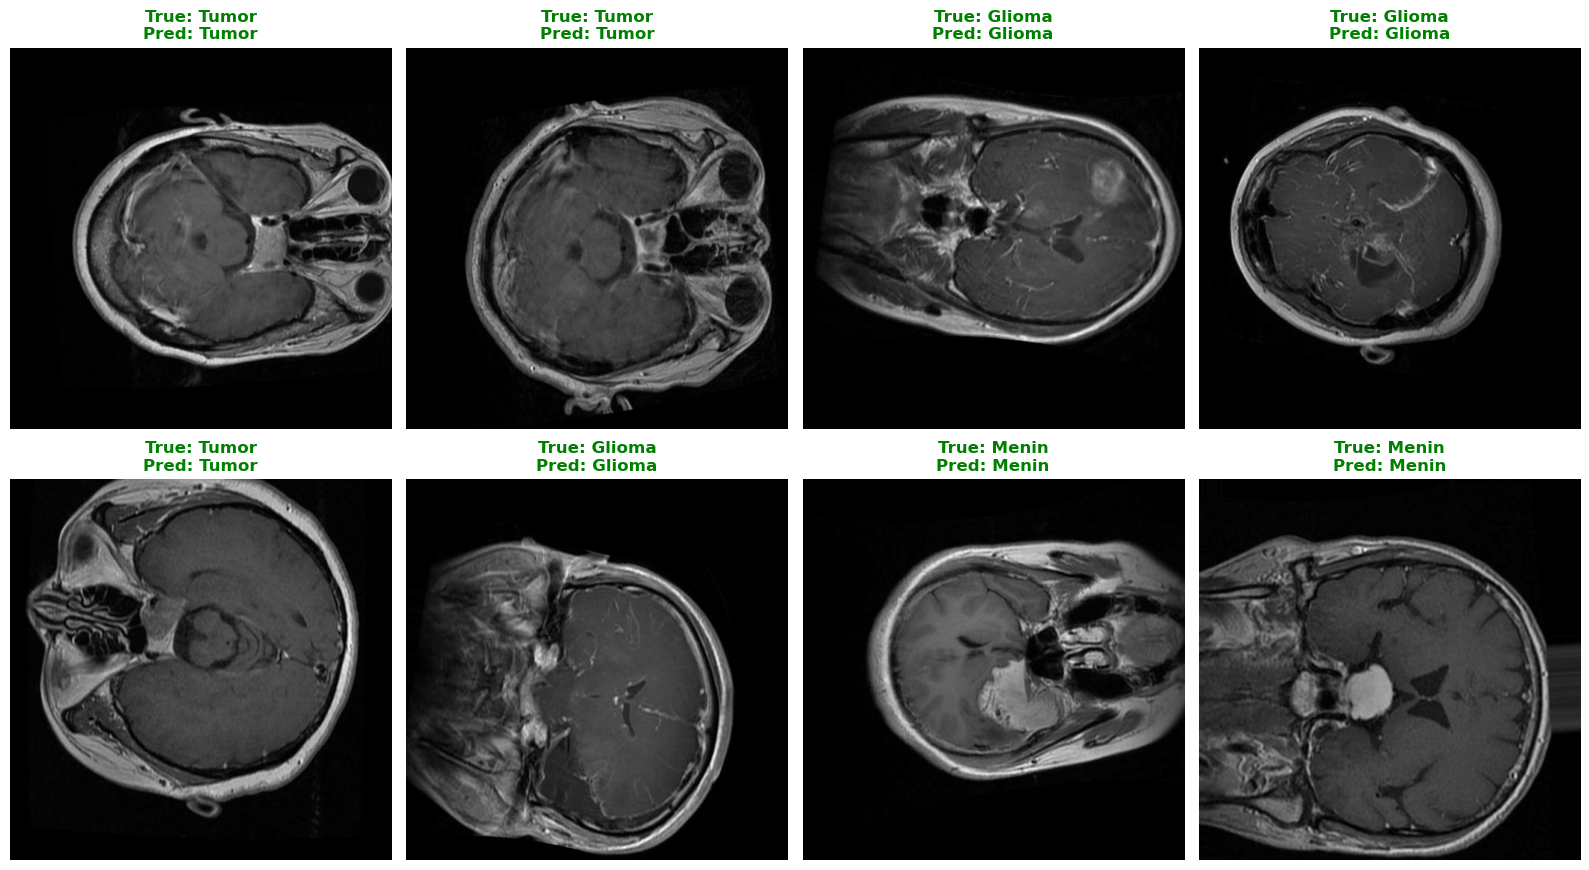

In [23]:
import matplotlib.pyplot as plt
import random

num_samples = 8
random_indices = random.sample(range(len(test_dataset_full)), num_samples)
plt.figure(figsize=(15, 8))
fig, axes = plt.subplots(2, 4, figsize=(16, 9))
axes = axes.ravel()


model.eval()

# loop
for i, idx in enumerate(random_indices):
    # image trasform
    raw_img, true_label_idx = test_dataset_full[idx]
    
    
    transformed_img, _ = test_dataset[idx]
    input_tensor = transformed_img.unsqueeze(0).to(device) # Batch dimension (1, 3, 128, 128)
    
    # model prediction
    with torch.no_grad():
        outputs = model(input_tensor)
        _, pred_label_idx = torch.max(outputs, 1)
    
    # index to image name
    true_label_name = categories[true_label_idx].split('_')[1].capitalize()
    pred_label_name = categories[pred_label_idx.item()].split('_')[1].capitalize()
    
    # if right prediction, color green, else red
    color = 'green' if true_label_idx == pred_label_idx.item() else 'red'
    
    # visualization
    axes[i].imshow(raw_img)
    axes[i].axis('off')
    axes[i].set_title(f"True: {true_label_name}\nPred: {pred_label_name}", 
                      color=color, fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()